# 02. 저수지 운영 환경 이해하기 (Toy Reservoir Environment)

논문의 환경 코드는 공개되지 않았으므로, 같은 **구조**를 가진 작은 환경 `toy_reservoir.py` 를 만들어 두었습니다.

| 논문 환경 | 이 튜토리얼의 toy 환경 |
|---|---|
| 일 단위 스텝, 4년(1460 step) | 일 단위 스텝, 1년(365 step) |
| 이산 액션 100개 → 방류량 | 동일 (`N_ACTIONS = 100`) |
| 관측 타입 5 (6차원) | 동일: [수위, 유입량, 미래 유입량, 상한 수위, sin(일), cos(일)] |
| 7개 보상 계수 | 동일 이름 (`power, level, flood, ecological, powerlimit, navigation, action`) |
| `CONSTRAINT_TYPES` 1/2/3 | 동일 의미 |
| `constraint_cost_normalized` | 동일 (info 딕셔너리) |
| 실제 유입량 데이터(비공개) | 계절 사인파 + 잡음 + 홍수 펄스로 합성 |

**주의:** 수치는 삼협(Three Gorges) 규모에서 영감을 받았지만 단순화된 것이며, 논문 결과를 재현하는 것이 목적이 아니라 메커니즘을 이해하는 것이 목적입니다.

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, ".")
import toy_reservoir as tr
plt.rcParams["figure.figsize"] = (11, 3.2)

## 1. 물수지 (water balance)

하루 동안의 저수량 변화는 `ΔV = (유입량 − 방류량) × 86400 s` 입니다. 저수량과 수위는 선형 관계로 근사합니다.

$$ V_{t+1} = V_t + (I_t - Q_t)\,\Delta t, \qquad Z = Z_{dead} + \frac{V - V_{dead}}{s} $$

dead level 145.0 m -> 171.5 1e8 m³ ; normal level 175.0 m -> 393.0 1e8 m³
1 day at (I - Q) = 10000 m³/s changes storage by 8.64 1e8 m³ = 1.17 m of level


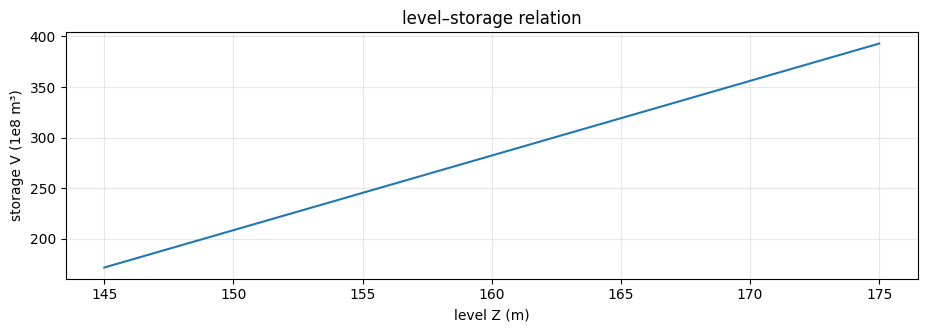

In [2]:
z = np.linspace(tr.Z_DEAD, tr.Z_NORMAL, 50)
plt.plot(z, tr.storage_from_level(z)); plt.xlabel("level Z (m)"); plt.ylabel("storage V (1e8 m³)"); plt.title("level–storage relation"); plt.grid(alpha=.3)
print(f"dead level {tr.Z_DEAD} m -> {tr.V_DEAD} 1e8 m³ ; normal level {tr.Z_NORMAL} m -> {tr.V_NORMAL} 1e8 m³")
print(f"1 day at (I - Q) = 10000 m³/s changes storage by {10000*86400/1e8:.2f} 1e8 m³ = {10000*86400/1e8/tr.STORAGE_SLOPE:.2f} m of level")

## 2. 합성 유입량

여름(7월)에 최대, 겨울에 최소인 계절 패턴에 로그정규 잡음과 홍수 펄스를 더합니다. 홍수기(6/1–9/30)에는 상한 수위가 `Z_FLOOD_LIMIT` 로 낮아집니다.

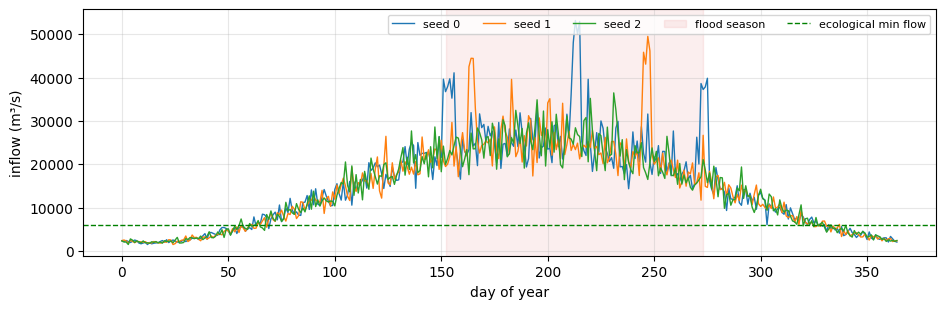

In [3]:
fig, ax = plt.subplots()
for s in range(3):
    ax.plot(tr.synthetic_inflow(365, seed=s), lw=1, label=f"seed {s}")
ax.axvspan(*tr.FLOOD_SEASON, color="tab:red", alpha=.08, label="flood season")
ax.axhline(tr.Q_ECOLOGICAL, ls="--", c="g", lw=1, label="ecological min flow")
ax.set_xlabel("day of year"); ax.set_ylabel("inflow (m³/s)"); ax.legend(ncol=5, fontsize=8); ax.grid(alpha=.3)

## 3. 보상과 제약 비용

한 스텝의 보상은

$$ r_t = c_{power}\,\frac{E_t}{E_{max}} - \sum_{k \in \text{constraints}} c_k\, \text{cost}_k $$

이고, `constraint_cost_normalized` 는 수위/홍수/생태/보증출력/항운 비용의 평균(0–1)입니다.
PPO-Lagrangian 은 **보상**을 최대화하면서 이 **비용의 기대값**을 `constraint_threshold`(=0.05) 아래로 유지하려고 합니다.

`CONSTRAINT_TYPES` 의 세 가지 의미:

* **1** — 수위 범위를 벗어나면 에피소드 종료
* **2** — 방류량을 보정해 수위를 범위 안에 유지, 페널티 없음 (A1 Correction)
* **3** — 보정 + 페널티 (A2 Penalty, A3 Lagrangian 및 B, C 그룹)

In [4]:
def random_policy(obs, mask):
    return np.random.choice(np.flatnonzero(mask))

def greedy_release_policy(obs, mask):
    """A naive rule: release roughly what comes in (keeps the level flat)."""
    inflow = obs[1] * tr.Q_MAX
    return int(np.argmin(np.abs(tr.release_grid() - inflow)))

np.random.seed(0)
summary = []
for ct in (1, 2, 3):
    env = tr.ToyReservoirEnv(constraint_types=ct)
    for name, pol in [("random", random_policy), ("release=inflow", greedy_release_policy)]:
        log = tr.run_episode(env, pol, seed=1, init_level=160)
        summary.append(dict(constraint_types=ct, policy=name, steps=len(log), episode_return=log.reward.sum(),
                            mean_cost=log.constraint_cost.mean(), energy_1e8kWh=log.energy.sum()))
pd.DataFrame(summary).round(3)

,constraint_types,policy,steps,episode_return,mean_cost,energy_1e8kWh
0,1,random,7,3.592,0.016,26.585
1,1,release=inflow,365,66.553,0.047,879.808
2,2,random,365,170.253,0.179,919.369
3,2,release=inflow,365,162.927,0.047,879.808
4,3,random,365,-212.774,0.138,825.832
5,3,release=inflow,365,66.553,0.047,879.808


타입 1 에서는 무작위 정책이 금방 수위 범위를 벗어나 에피소드가 끝납니다. 타입 2 는 보상에 페널티가 없어서 **비용이 높아도 보상은 큰** 반면, 타입 3 은 페널티가 보상을 깎습니다.

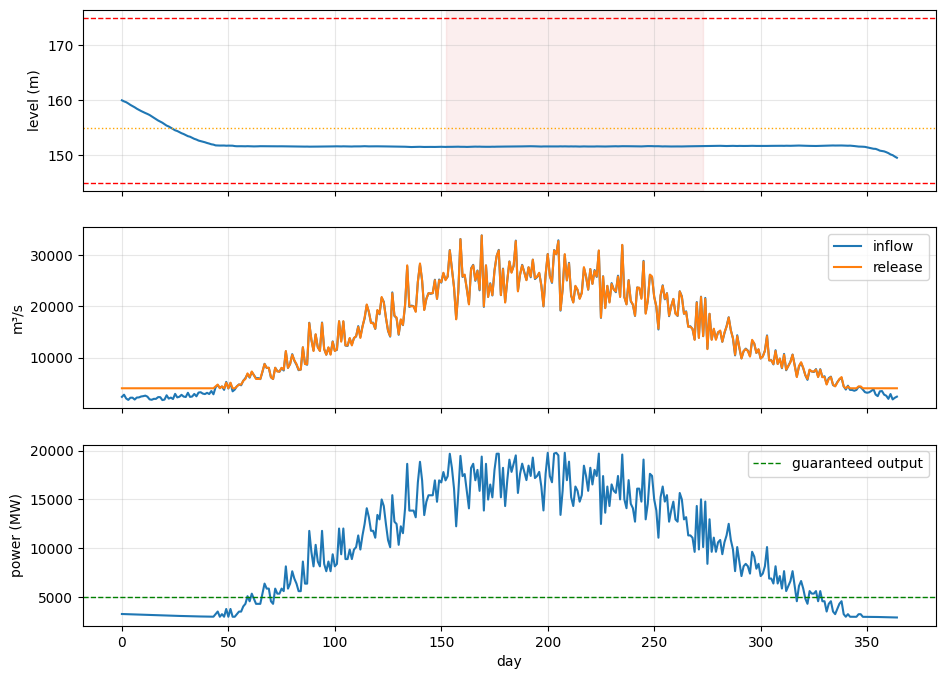

In [5]:
env = tr.ToyReservoirEnv(constraint_types=3)
log = tr.run_episode(env, greedy_release_policy, seed=1, init_level=160)

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axes[0].plot(log.t, log.level); axes[0].axhline(tr.Z_NORMAL, c="r", ls="--", lw=1); axes[0].axhline(tr.Z_DEAD, c="r", ls="--", lw=1)
axes[0].axvspan(*tr.FLOOD_SEASON, color="tab:red", alpha=.08); axes[0].axhline(tr.Z_FLOOD_LIMIT, c="orange", ls=":", lw=1); axes[0].set_ylabel("level (m)")
axes[1].plot(log.t, log.inflow, label="inflow"); axes[1].plot(log.t, log.release, label="release"); axes[1].legend(); axes[1].set_ylabel("m³/s")
axes[2].plot(log.t, log.power_mw); axes[2].axhline(tr.P_GUARANTEE_MW, c="g", ls="--", lw=1, label="guaranteed output"); axes[2].legend(); axes[2].set_ylabel("power (MW)"); axes[2].set_xlabel("day")
for a in axes: a.grid(alpha=.3)

cost_level         0.0000
cost_flood         0.0000
cost_ecological    0.0759
cost_powerlimit    0.0938
cost_navigation    0.0634
cost_action        0.0309
dtype: float64

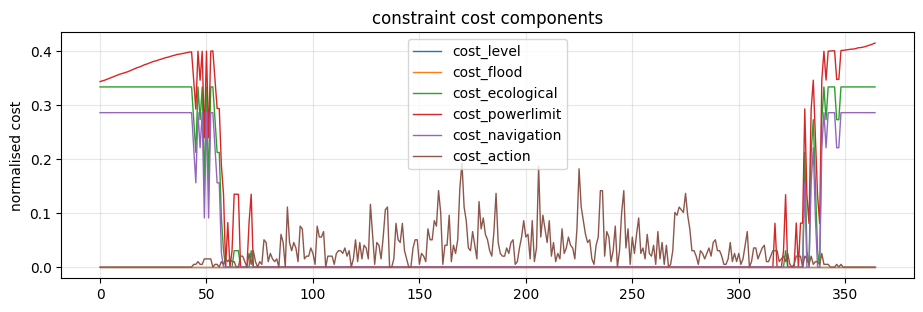

In [6]:
cost_cols = [c for c in log.columns if c.startswith("cost_")]
log[cost_cols].plot(lw=1); plt.ylabel("normalised cost"); plt.title("constraint cost components"); plt.grid(alpha=.3)
log[cost_cols].mean().round(4)

## 4. 관측 벡터

`OBSERVATION_TYPES = 5` 에 해당하는 6차원 관측입니다. 모두 0–1(또는 −1–1) 로 정규화되어 있습니다.

In [7]:
obs, info = env.reset(seed=3, init_level=165)
names = ["level", "inflow", "future_inflow(7d)", "upper_limit_level", "sin(doy)", "cos(doy)"]
pd.Series(obs, index=names).round(3)

level                0.667
inflow               0.075
future_inflow(7d)    0.052
upper_limit_level    1.000
sin(doy)             0.017
cos(doy)             1.000
dtype: float32

## 정리

* 환경은 물수지 + 수력발전 + 5개 제약(수위, 홍수, 생태, 보증출력, 항운) + 액션 변화 페널티로 이루어집니다.
* `CONSTRAINT_TYPES` 는 위반을 **종료 / 보정 / 보정+페널티** 중 어떻게 처리할지 결정합니다.
* PPO-Lagrangian 에 필요한 `constraint_cost_normalized` 는 보상과 별도로 info 에 담겨 나옵니다.